# Growth within American Parliamentary Debate Association (APDA)

This section will analzye the growth of APDA from Fall 2019 to Spring 2026 using the following metrics: tournaments, rounds, and number of debaters. The goal of this section is to understand the scope of APDA and its expected impact in coming years.

## Tournaments

The first metric to understand is the number of tournaments in APDA between Fall 2019 and Spring 2026 as well as the number of tournaments per semester. In order to begin understanding this, I will import the rounds from Fall 2019 to Spring 2026, this data includes information on all the rounds conducted at tournaments with accessible tab cards between Fall 2019 and Spring 2026. This data also include information on the speakers, judges, and decisions. These are not relevant for this analysis so we will drop this extra information and begin by tallying the number of rounds per tournament to utilize in the Rounds section.

In [249]:
import pandas as pd
df_rounds = pd.read_csv("Rounds_Data.csv")
collapsed_df = df_rounds.groupby(["Tournament", "Season", "Year"], as_index=False).count()
collapsed_df = collapsed_df[['Tournament', 'Season', 'Year', 'Round']].copy()
collapsed_df = collapsed_df.rename(columns={"Round": "Total Rounds"})
print(collapsed_df.head())

  Tournament  Season  Year  Total Rounds
0   American    Fall  2019           227
1   American    Fall  2024           129
2   American  Spring  2024            70
3   American  Spring  2025            83
4   American  Spring  2026            96


In addition to the tournaments seen in the "Rounds_Data.csv", there were also tournaments that could not be processed due to bad format, lack of permission, or because they simply had never been recorded. The code below will append these lost tournaments to our collapsed_df dataset which contains information about tournament, season, year, and number of rounds from that tournament. I will append these tournaments to our dataframe so they will be included in our analysis.

In [241]:
data = [
    {'Tournament': 'Fordham', 'Season': 'Fall', 'Year': 2019},
    {'Tournament': 'UVA', 'Season': 'Fall', 'Year': 2019},
    {'Tournament': 'Columbia', 'Season': 'Fall', 'Year': 2019},
    {'Tournament': 'Georgetown', 'Season': 'Spring', 'Year': 2020},
    {'Tournament': 'Williams', 'Season': 'Spring', 'Year': 2020},
    {'Tournament': 'Harvard', 'Season': 'Fall', 'Year': 2020},
    {'Tournament': 'Swarthmore', 'Season': 'Fall', 'Year': 2020},
    {'Tournament': 'Swarthmore', 'Season': 'Spring', 'Year': 2021},
    {'Tournament': 'Brandeis', 'Season': 'Spring', 'Year': 2021},
    {'Tournament': 'William and Mary', 'Season': 'Spring', 'Year': 2021},
    {'Tournament': 'Georgetown', 'Season': 'Spring', 'Year': 2021},
    {'Tournament': 'Yale', 'Season': 'Spring', 'Year': 2021},
    {'Tournament': 'Brown', 'Season': 'Fall', 'Year': 2021},
    {'Tournament': 'Brown', 'Season': 'Spring', 'Year': 2022},
    {'Tournament': 'Princeton', 'Season': 'Spring', 'Year': 2022},
    {'Tournament': 'Yale', 'Season': 'Spring', 'Year': 2022},
    {'Tournament': 'Rutgers', 'Season': 'Spring', 'Year': 2022},
    {'Tournament': 'Williams', 'Season': 'Spring', 'Year': 2022},
    {'Tournament': 'Dartmouth', 'Season': 'Spring', 'Year': 2022},
    {'Tournament': 'Brown', 'Season': 'Fall', 'Year': 2022},
    {'Tournament': 'Yale', 'Season': 'Fall', 'Year': 2022},
    {'Tournament': 'Williams', 'Season': 'Fall', 'Year': 2022},
    {'Tournament': 'Tufts', 'Season': 'Fall', 'Year': 2022},
    {'Tournament': 'Harvard', 'Season': 'Fall', 'Year': 2022},
    {'Tournament': 'Rutgers', 'Season': 'Fall', 'Year': 2022},
    {'Tournament': 'Hopkins', 'Season': 'Spring', 'Year': 2023},
    {'Tournament': 'Brandeis', 'Season': 'Spring', 'Year': 2023},
    {'Tournament': 'Rutgers', 'Season': 'Spring', 'Year': 2023},
    {'Tournament': 'Penn', 'Season': 'Spring', 'Year': 2023},
    {'Tournament': 'Williams', 'Season': 'Spring', 'Year': 2023},
    {'Tournament': 'University of Chicago', 'Season': 'Spring', 'Year': 2023},
    {'Tournament': 'University of Massachusetts', 'Season': 'Spring', 'Year': 2023},
    {'Tournament': 'Hopkins', 'Season': 'Fall', 'Year': 2023},
    {'Tournament': 'Swarthmore', 'Season': 'Fall', 'Year': 2023},
    {'Tournament': 'Brandeis', 'Season': 'Fall', 'Year': 2023},
    {'Tournament': 'Harvard', 'Season': 'Fall', 'Year': 2023},
    {'Tournament': 'Amherst', 'Season': 'Spring', 'Year': 2024},
    {'Tournament': 'University of Massachusetts', 'Season': 'Spring', 'Year': 2024},
    {'Tournament': 'Brandeis', 'Season': 'Spring', 'Year': 2024},
    {'Tournament': 'NYU', 'Season': 'Spring', 'Year': 2024},
    {'Tournament': 'Windsor', 'Season': 'Spring', 'Year': 2024},
    {'Tournament': 'Tufts', 'Season': 'Spring', 'Year': 2024},
    {'Tournament': 'Harvard', 'Season': 'Fall', 'Year': 2024},
    {'Tournament': 'Binghamton', 'Season': 'Fall', 'Year': 2024},
    {'Tournament': 'Tufts', 'Season': 'Fall', 'Year': 2024},
    {'Tournament': 'Brown', 'Season': 'Fall', 'Year': 2024},
    {'Tournament': 'Rutgers', 'Season': 'Spring', 'Year': 2025},
    {'Tournament': 'Amherst', 'Season': 'Spring', 'Year': 2025},
    {'Tournament': 'Penn', 'Season': 'Spring', 'Year': 2025},
    {'Tournament': 'UVA', 'Season': 'Spring', 'Year': 2025},
    {'Tournament': 'Dartmouth', 'Season': 'Spring', 'Year': 2025},
    {'Tournament': 'UT Austin', 'Season': 'Spring', 'Year': 2025},
    {'Tournament': 'Drexel', 'Season': 'Fall', 'Year': 2025},
    {'Tournament': 'Brandeis', 'Season': 'Fall', 'Year': 2025},
    {'Tournament': 'Bates', 'Season': 'Fall', 'Year': 2025},
    {'Tournament': 'American', 'Season': 'Fall', 'Year': 2025},
    {'Tournament': 'Temple', 'Season': 'Spring', 'Year': 2026},
]
missing_df = pd.DataFrame(data)

tournament_rounds_df = pd.concat([collapsed_df, missing_df], ignore_index=True)

tournament_rounds_df["Semester"] = tournament_rounds_df["Season"] + " " + tournament_rounds_df["Year"].astype(str)

print(tournament_rounds_df.tail())
tournament_rounds_df.to_csv("Tournaments.csv", index=False)

    Tournament  Season  Year  Total Rounds     Semester
238     Drexel    Fall  2025           NaN    Fall 2025
239   Brandeis    Fall  2025           NaN    Fall 2025
240      Bates    Fall  2025           NaN    Fall 2025
241   American    Fall  2025           NaN    Fall 2025
242     Temple  Spring  2026           NaN  Spring 2026


We can now see our tournaments with missing round data have been appened onto the end of our dataframe, so we now have a record of all of our tournaments that took place.

In [252]:
print("Total Tournaments from Fall 2019 to Spring 2026: ", tournament_rounds_df["Tournament"].count())

Total Tournaments from Fall 2019 to Spring 2026:  243


There were a total of 243 tournaments between Fall 2019 and Spring 2026.

Now we can begin to analyze the number of tournaments over time in APDA. To do this, we will group out tournament_rounds_df by Semester leaving a count of the number of tournaments that occurred in each semester. I will also adjust the order of the semesters to be chronological.

In [253]:
semester_order = ['Fall 2019', 'Spring 2020', 'Spring 2021', 'Fall 2021', 'Spring 2022', 'Fall 2022', 'Spring 2023', 'Fall 2023', 'Spring 2024', 'Fall 2024', 'Spring 2025', 'Fall 2025', 'Spring 2026']
tournament_rounds_df['Semester'] = pd.Categorical(
    tournament_rounds_df['Semester'], 
    categories=semester_order, 
    ordered=True
)
tournaments_df = tournament_rounds_df.groupby(["Semester"], observed=False, as_index=False).count()

We will also create a mask to separate years during the COVID-19 in-person restrictions so that we can see our data with and without this extra burden on APDA.

In [254]:
covid_years = ["Spring 2020", "Fall 2020", "Spring 2021", "Fall 2021"]
tournaments_df_exclude_covid = tournaments_df[~tournaments_df["Semester"].isin(covid_years)].copy()
tournaments_df_exclude_covid["Semester"] = tournaments_df_exclude_covid["Semester"].cat.remove_unused_categories()

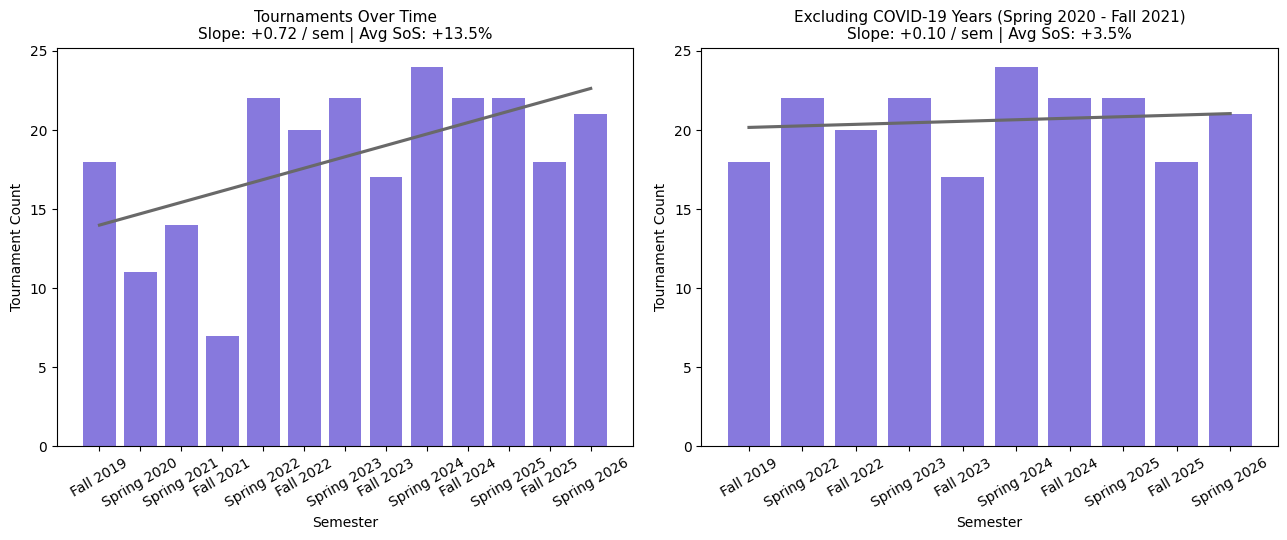

In [255]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

x_positions_t = np.arange(len(tournaments_df))
slope_t, _ = np.polyfit(x_positions_t, tournaments_df["Tournament"], 1)
avg_pct_t = tournaments_df["Tournament"].pct_change().mean() * 100

x_positions_r = np.arange(len(tournaments_df_exclude_covid))
slope_r, _ = np.polyfit(
    x_positions_r, tournaments_df_exclude_covid["Tournament"], 1
)
avg_pct_r = tournaments_df_exclude_covid["Tournament"].pct_change().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(
    tournaments_df,
    x="Semester",
    y="Tournament",
    color="mediumslateblue",
    ax=axes[0],
)
sns.regplot(
    x=x_positions_t,
    y=tournaments_df["Tournament"],
    ax=axes[0],
    scatter=False,
    color="dimgray",
    label="Trend",
    ci=None,
)

axes[0].set_title(
    f"Tournaments Over Time\nSlope: {slope_t:+.2f} / sem | Avg SoS: {avg_pct_t:+.1f}%",
    fontsize=11,
)
axes[0].set_ylabel("Tournament Count")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    tournaments_df_exclude_covid,
    x="Semester",
    y="Tournament",
    color="mediumslateblue",
    ax=axes[1],
)
sns.regplot(
    x=x_positions_r,
    y=tournaments_df_exclude_covid["Tournament"],
    ax=axes[1],
    scatter=False,
    color="dimgray",
    label="Trend",
    ci=None,
)

axes[1].set_title(
    f"Excluding COVID-19 Years (Spring 2020 - Fall 2021)\nSlope: {slope_r:+.2f} / sem | Avg SoS: {avg_pct_r:+.1f}%",
    fontsize=11,
)
axes[1].set_ylabel("Tournament Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

From the above, we can see that the number of tournaments are increasing. In the excluding COVID-19 years graph (right), there is a slope of +0.10 a semester and has an average semester over semester increase of +3.5%. This indicates, that the number of tournaments continue to grow in ADPA. 

It also seems, from the graphics, that there might be a cyclic nature to tournaments, more in the Spring than in the Fall. I will investigate this next by performing a rudimentary analysis checking where the number of tournaments dip.

In [256]:
tournaments_df_exclude_covid['dropped'] = tournaments_df_exclude_covid['Tournament'].diff() < 0
tournaments_df_exclude_covid['cycle'] = tournaments_df_exclude_covid['dropped'].cumsum()

is_increasing = tournaments_df_exclude_covid.groupby('cycle')['Tournament'].is_monotonic_increasing
print(is_increasing)

cycle
0    True
1    True
2    True
3    True
4    True
Name: Tournament, dtype: bool


From this we can see that it is true, there are five distinct cycles of increasing before a drop appearing in our grpah. This lines up with the ten semester of data we have. So there is an increase in the Spring from the Fall and then a dip in the following Fall.

## Rounds

In order to analyize the number of rounds in APDA, we first need to attempt to recover the data that was lost due to bad format, lack of permission, and missing tab cards. The lost number of rounds from these tournaments is data missing at random as certain schools were more likely to consistently have these issues. I will attempt to restore this data using K-Nearest Neighbors Imputation.

## Insights and Conclusions

Tournament -- 243, inc, and cyclic (further, what regions? public expansion?)